# EDA

## Importing libaries

In [18]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import string
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import warnings

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Loading Input datasets

Both datasets are collected from Kaggle. First we will perform EDA step.

In [3]:
enron_dataset = pd.read_csv('./data/raw/enron_spam_data.csv')

## Data Overview
- Check number of sample
- Check number of feature
- Check data type
- Check label imbalance

In [4]:
enron_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


-> Có 33716 sample trong raw dataset

-> Có 5 feature trong raw dataset

Tất cả các feature đều có type là str ngoại trừ Message ID là int64

Khi quan sát số lượng Non-Null ở cột Subject, Message, ta sẽ thấy số lượng hao hụt ít hơn so với tổng số lượng sample, chứng tỏ dữ liệu đang bị khuyết thiếu

In [5]:
enron_dataset.value_counts(enron_dataset['Spam/Ham'])

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

## Plotting class distribution using Bar chart

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


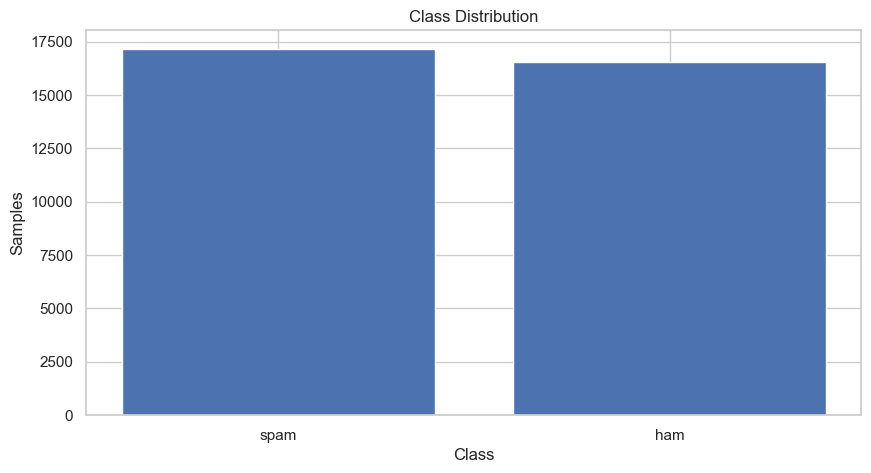

In [6]:
# Plotting bar chart, using Matplotlib library
colors = sns.color_palette(palette='bright')
# Counting the frequency of SPAM/HAM labels to visualize the bar chart
label_counts = enron_dataset['Spam/Ham'].value_counts()
labels = ['spam','ham']

print(label_counts)

# Setting figure size
plt.figure(figsize=(10, 5))

# Creating bar chart
plt.bar(labels, label_counts)

# Adding title and labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

plt.show()

## Missing Data Analysis
Mục tiêu: Phát hiện, phân tích quy luật và xử lý các ô dữ liệu bị trống (NaN) một cách có chủ đích

- Detect các missing values
- Tính tỷ lệ missing theo từng feature một:
    - Nếu feature Message bị null thì drop luôn vì nội dung email mà không có thì không có giá trị gì cả
    - Nếu feature Subject bị null thì không cần drop mà Impute "No Subject" vào
- Lọc ra toàn bộ các email bị missing cột Subject. Sau đó đếm xem trong tập bị missing này, tỷ lệ Spam/Ham là bao nhiêu?


In [7]:
missing_count = enron_dataset.isnull().sum()
missing_pct = (enron_dataset.isnull().sum() / len(enron_dataset)) * 100

missing_df = pd.DataFrame({
    'Số lượng Missing': missing_count,
    'Tỷ lệ Missing (%)': missing_pct
})
print(missing_df[missing_df['Số lượng Missing'] > 0])

         Số lượng Missing  Tỷ lệ Missing (%)
Subject               289           0.857160
Message               371           1.100368


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4112\2682394767.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_features.index, y=missing_features.values, palette="viridis")


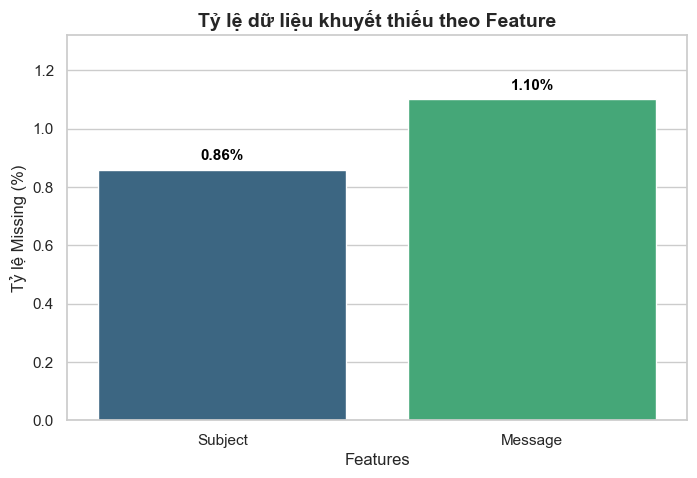

In [8]:
missing_features = missing_pct[missing_pct > 0]
if not missing_features.empty:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=missing_features.index, y=missing_features.values, palette="viridis")
    plt.title('Tỷ lệ dữ liệu khuyết thiếu theo Feature', fontsize=14, fontweight='bold')
    plt.ylabel('Tỷ lệ Missing (%)', fontsize=12)
    plt.xlabel('Features', fontsize=12)
    plt.ylim(0, max(missing_features.values) * 1.2)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()

-> Tập dữ liệu thu thập ban đầu tương đối tốt
- Cột Message bị thiếu 371 sample
- Cột Subject bị thiếu 289 sample

Phát hiện 289 email bị thiếu Subject


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4112\3119169807.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=missing_subject_df, x='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'},legend=False)


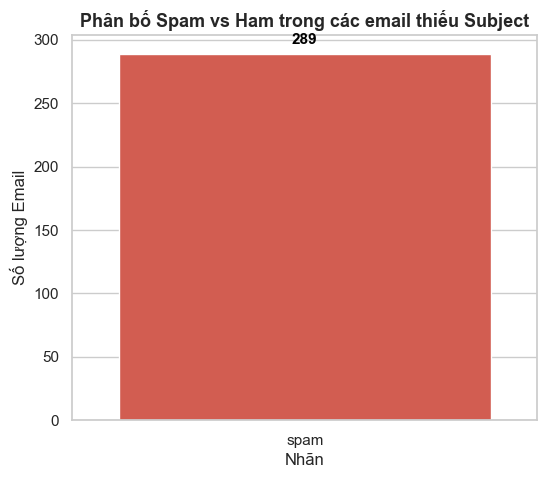

In [ ]:
missing_subject_df = enron_dataset[enron_dataset['Subject'].isnull()]

if not missing_subject_df.empty:
    print(f"-> Phát hiện {len(missing_subject_df)} email bị thiếu Subject")
    
    plt.figure(figsize=(6, 5))
    ax2 = sns.countplot(data=missing_subject_df, x='Spam/Ham', palette={'ham': '#2ecc71', 'spam': '#e74c3c'},legend=False)
    plt.title('Phân bố Spam vs Ham trong các email thiếu Subject', fontsize=13, fontweight='bold')
    plt.ylabel('Số lượng Email', fontsize=12)
    plt.xlabel('Nhãn', fontsize=12)
    
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')
    plt.show()

Khi phân tích sâu vào 289 email bị thiếu Subject, biểu đồ phân bố cho thấy là 100% (289/289) email không có tiêu đề đều là thư rác (Spam) Không có bất kỳ một email công việc thật (Ham) nào quên ghi tiêu đề vì có thể trong môi trường công sở chuyên nghiệp (bối cảnh của tập dữ liệu Enron), nhân viên luôn tuân thủ nguyên tắc viết email phải có tiêu đề rõ ràng để trao đổi công việc. Ngược lại những kẻ lừa đảo thường sử dụng các công cụ tự động (bots) để gửi thư rác hàng loạt và chúng thường lười điền tiêu đề, hoặc cố tình để trống nhằm kích thích sự tò mò, ép người dùng phải click vào mở email để xem nội dung

Từ insight trên, nhóm quyết định thực hiện xử lý riêng từng cột feature như sau:
- Đối với cột Message: Bắt buộc drop toàn bộ 371 email này vì 1 sample dữ liệu không có nội dung văn bản thì hoàn toàn vô giá trị, nếu giữ lại sẽ tạo thành noise làm giảm độ chính xác của model
- Đối với cột Subject: Không xóa, mà thực hiện điền khuyết bằng chuỗi văn bản cố định: "No Subject" vì việc "thiếu tiêu đề" đã được chứng minh là một hành vi đặc trưng của Spam. Khi điền chuỗi "No Subject", thuật toán TF-IDF ở bước sau sẽ đếm và gán trọng số rất cao cho cụm từ này. Qua đó, model sẽ tự động đúc kết được quy luật: "Cứ thấy email nào có chữ 'No Subject' thì xác suất cao là Spam"

In [12]:
initial_rows = len(enron_dataset)

enron_dataset = enron_dataset.dropna(subset=['Message'])
print(f"[-] Đã xóa {initial_rows - len(enron_dataset)} dòng bị thiếu 'Message'.")

enron_dataset['Subject'] = enron_dataset['Subject'].fillna('No Subject')
print("[+] Đã điền chuỗi 'No Subject' cho các email bị thiếu 'Subject'.")

[-] Đã xóa 371 dòng bị thiếu 'Message'.
[+] Đã điền chuỗi 'No Subject' cho các email bị thiếu 'Subject'.


In [13]:
print(enron_dataset.isnull().sum())
enron_dataset.shape

Message ID    0
Subject       0
Message       0
Spam/Ham      0
Date          0
dtype: int64


(33345, 5)

## Univariate Analysis
Mục tiêu: Khám phá đặc điểm phân bố của từng biến số một cách độc lập trên toàn bộ tập dữ liệu
- Biến đổi văn bản thô thành các con số có thể đo lường được bằng cách tạo 2 cột mới: Message_Length (Độ dài email) và Punct_Count (Số lượng dấu câu)
- Vẽ biểu đồ Histogram để xem phần lớn email có độ dài nằm trong khoảng nào
- Vẽ biểu đồ phân bố dấu câu
- Trực quan hóa 10 ký tự đặc biệt được sử dụng nhiều nhất trong toàn bộ tập dữ liệu để xem có sự lạm dụng các ký tự như !, $, * hay không
- Dùng kỹ thuật đếm từ để trực quan hóa Top 20 từ vựng xuất hiện nhiều nhất
- Vẽ Word Cloud tổng quát


In [16]:
warnings.filterwarnings('ignore')

In [17]:
# Đếm số lượng từ trong mỗi email (dựa vào khoảng trắng)
enron_dataset['Message_Length'] = enron_dataset['Message'].apply(lambda x: len(str(x).split()))

In [18]:
# Đếm tổng số lượng dấu câu trong mỗi email
enron_dataset['Punct_Count'] = enron_dataset['Message'].apply(lambda x: sum([1 for char in str(x) if char in string.punctuation]))

In [20]:
enron_dataset[['Message_Length', 'Punct_Count']].describe()

,Message_Length,Punct_Count
count,33345.000000,33345.000000
mean,306.772170,68.987674
std,855.622403,174.123274
min,1.000000,0.000000
25%,67.000000,12.000000
50%,148.000000,30.000000
75%,326.000000,77.000000
max,45448.000000,8313.000000


Dựa vào kết quả thống kê cơ bản trên đối với 33.345 email, nhóm rút ra insight như sau:
- Độ dài email có mean xấp xỉ 306.7 từ lớn hơn gấp đôi so với trung vị (Median / 50% = 148 từ). Đặc biệt, 75% số email có độ dài chỉ từ 326 từ trở xuống
- Số lượng dấu câu có mean xấp xỉ 68.9 dấu câu, lớn hơn gấp đôi trung vị là 30. 75% email sử dụng ít hơn 77 dấu câu

-> Vậy hầu hết các email đều tương đối ngắn gọn (phản ánh đúng đặc thù trao đổi công việc hoặc các tin nhắn rác giật tít). Sự chênh lệch khổng lồ giữa Mean và Median báo hiệu biểu đồ Histogram sẽ có một cái đuôi kéo rất dài về bên phải

- Mặc dù 75% email chỉ dài tối đa 326 từ, nhưng Max lại lên tới 45.448 từ (một con số lớn) và chứa đến 8.313 dấu câu. Độ lệch chuẩn lên tới 855.6 cho thấy sự phân tán dữ liệu là cực kỳ lớn, những con số 45.448 từ này chắc chắn là dữ liệu dị biệt (có thể là file nhật ký hệ thống - log files, một chuỗi email forward đính kèm văn bản dài, hoặc các mã HTML rác, ....)

- Min của độ dài email là 1 từ, và min của số lượng dấu câu là 0. Khi mà một email chỉ có đúng 1 chữ gần như không mang lại ngữ cảnh để thuật toán phân loại hiểu được đó là Spam hay Ham

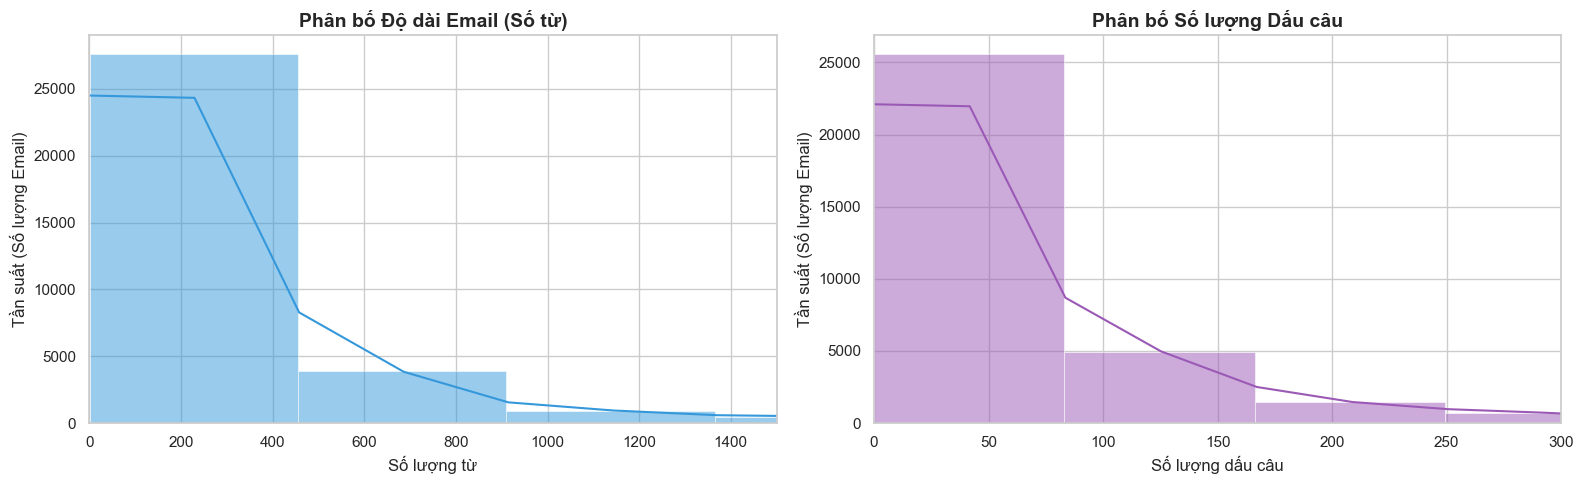

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(enron_dataset['Message_Length'], bins=100, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Phân bố Độ dài Email (Số từ)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng từ')
axes[0].set_ylabel('Tần suất (Số lượng Email)')
axes[0].set_xlim(0, 1500)

sns.histplot(enron_dataset['Punct_Count'], bins=100, kde=True, color='#9b59b6', ax=axes[1])
axes[1].set_title('Phân bố Số lượng Dấu câu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lượng dấu câu')
axes[1].set_ylabel('Tần suất (Số lượng Email)')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

-> Qua hai biểu đồ Histogram về độ dài email và số lượng dấu câu, chúng ta có thể quan sát rõ rệt hiện tượng phân bố lệch phải của toàn bộ tập dữ liệu. Khối lượng dữ liệu tập trung dày đặc ở khu vực có giá trị thấp, cho thấy hầu hết các email đều rất ngắn (dưới 250 từ và sử dụng ít hơn 50 dấu câu), phản ánh chính xác thói quen giao tiếp súc tích trong môi trường công sở cũng như đặc thù giật tít nhanh của các email lừa đảo. Tuy nhiên, đường cong phân bố (KDE) cũng làm nổi bật một phần đồ thị mỏng kéo rất dài về phía bên phải, đại diện trực quan cho nhóm dữ liệu outliers mang giá trị lớn bất thường mà chúng ta đã phát hiện trong bảng thống kê mô tả trước đó. Từ minh chứng trực quan này, nhóm có cơ sở thực tiễn vững chắc để quyết định áp dụng phương pháp toán học IQR trong bước tiếp theo nhằm loại bỏ phần đuôi dài này. Việc chủ động loại bỏ các email dài lê thê hoặc chứa lượng dấu câu đột biến sẽ giúp thu gọn không gian ma trận từ vựng (TF-IDF), tối ưu hóa bộ nhớ RAM và tăng cường tốc độ train cho model mà không làm biến dạng cấu trúc gốc của dữ liệu

In [23]:
# Gộp toàn bộ văn bản để đếm ký tự đặc biệt
all_text = " ".join(enron_dataset['Message'].astype(str))
all_punct = [char for char in all_text if char in string.punctuation]

In [24]:
# Đếm và lấy Top 10
top_punct = Counter(all_punct).most_common(10)
df_punct = pd.DataFrame(top_punct, columns=['Ký tự', 'Tần suất'])

In [30]:
for index, row in df_punct.iterrows():
    # In ra với format số có dấu phẩy (ví dụ: 100,000) và bọc ký tự trong ngoặc vuông cho dễ nhìn
    print(f"  Top {index + 1}: Ký tự [ {row['Ký tự']} ] - Xuất hiện: {row['Tần suất']:,} lần")

  Top 1: Ký tự [ . ] - Xuất hiện: 515,625 lần
  Top 2: Ký tự [ - ] - Xuất hiện: 400,743 lần
  Top 3: Ký tự [ , ] - Xuất hiện: 379,411 lần
  Top 4: Ký tự [ / ] - Xuất hiện: 169,062 lần
  Top 5: Ký tự [ : ] - Xuất hiện: 158,626 lần
  Top 6: Ký tự [ ' ] - Xuất hiện: 78,266 lần
  Top 7: Ký tự [ _ ] - Xuất hiện: 68,307 lần
  Top 8: Ký tự [ ) ] - Xuất hiện: 55,469 lần
  Top 9: Ký tự [ ? ] - Xuất hiện: 54,844 lần
  Top 10: Ký tự [ ( ] - Xuất hiện: 52,240 lần


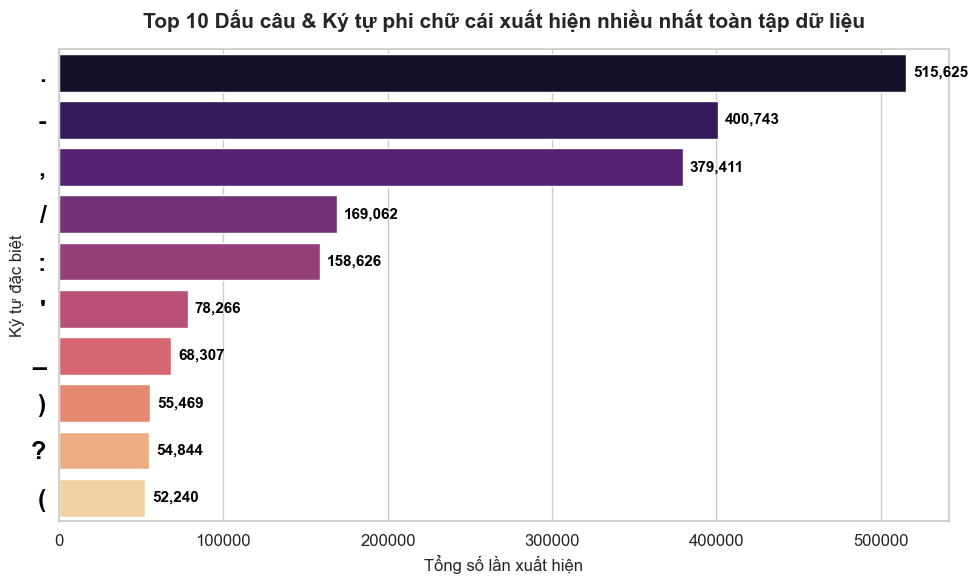

In [32]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tần suất', y='Ký tự', data=df_punct, palette='magma')

plt.yticks(fontsize=18, fontweight='bold', color='black')
plt.xticks(fontsize=12)

plt.title('Top 10 Dấu câu & Ký tự phi chữ cái xuất hiện nhiều nhất toàn tập dữ liệu', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Tổng số lần xuất hiện', fontsize=12)
plt.ylabel('Ký tự đặc biệt', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

Dựa trên bảng thống kê Top 10 ký tự đặc biệt xuất hiện nhiều nhất trên tập dữ liệu, nhóm rút ra các insight sau:
- Các dấu chấm (.) và phẩy (,) dẫn đầu là điều hiển nhiên trong văn phong tiếng Anh thông thường. Tuy nhiên, dấu gạch ngang (-) lại chễm chệ ở Top 2 với hơn 400.000 lần xuất hiện. Khác với văn bản văn học, email thường chứa rất nhiều dải phân cách (ví dụ: ----- Original Message -----), chữ ký tự động (signatures), hoặc gạch đầu dòng báo cáo công việc.
- Sự kết hợp của dấu hai chấm (: ở vị trí Top 5) và dấu gạch chéo (/ ở vị trí Top 4) là minh chứng cho sự tồn tại của một lượng khổng lồ các đường link website (cấu trúc http://... hoặc https://...)
- Dấu gạch dưới (_ ở Top 7) là một ký tự cực kỳ hiếm gặp trong văn bản thường, nhưng lại là thành phần "quốc dân" trong các địa chỉ email (ví dụ: john_doe@...) hoặc tên file đính kèm
- Đáng chú ý nhất là sự biến mất hoàn toàn của dấu chấm than (!) và ký hiệu tiền tệ ($) khỏi Top 10. Theo trực giác, đây là 2 vũ khí tối thượng của thư rác (dùng để giật tít và chào mời tài chính). Sự vắng mặt này là do chúng ta đang phân tích gộp toàn bộ tập dữ liệu. Khối lượng email trao đổi công việc nội bộ (Ham) chuẩn mực của tập đoàn Enron đã làm loãng hoàn toàn các ký tự rác này

In [26]:
# Dùng CountVectorizer để đếm từ và TỰ ĐỘNG loại bỏ Stopwords tiếng Anh
vectorizer = CountVectorizer(stop_words='english', max_features=20)
word_counts = vectorizer.fit_transform(enron_dataset['Message'].astype(str))

In [27]:
# Lấy từ vựng và tần suất
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
df_words = pd.DataFrame(words_freq, columns=['Từ vựng', 'Tần suất'])

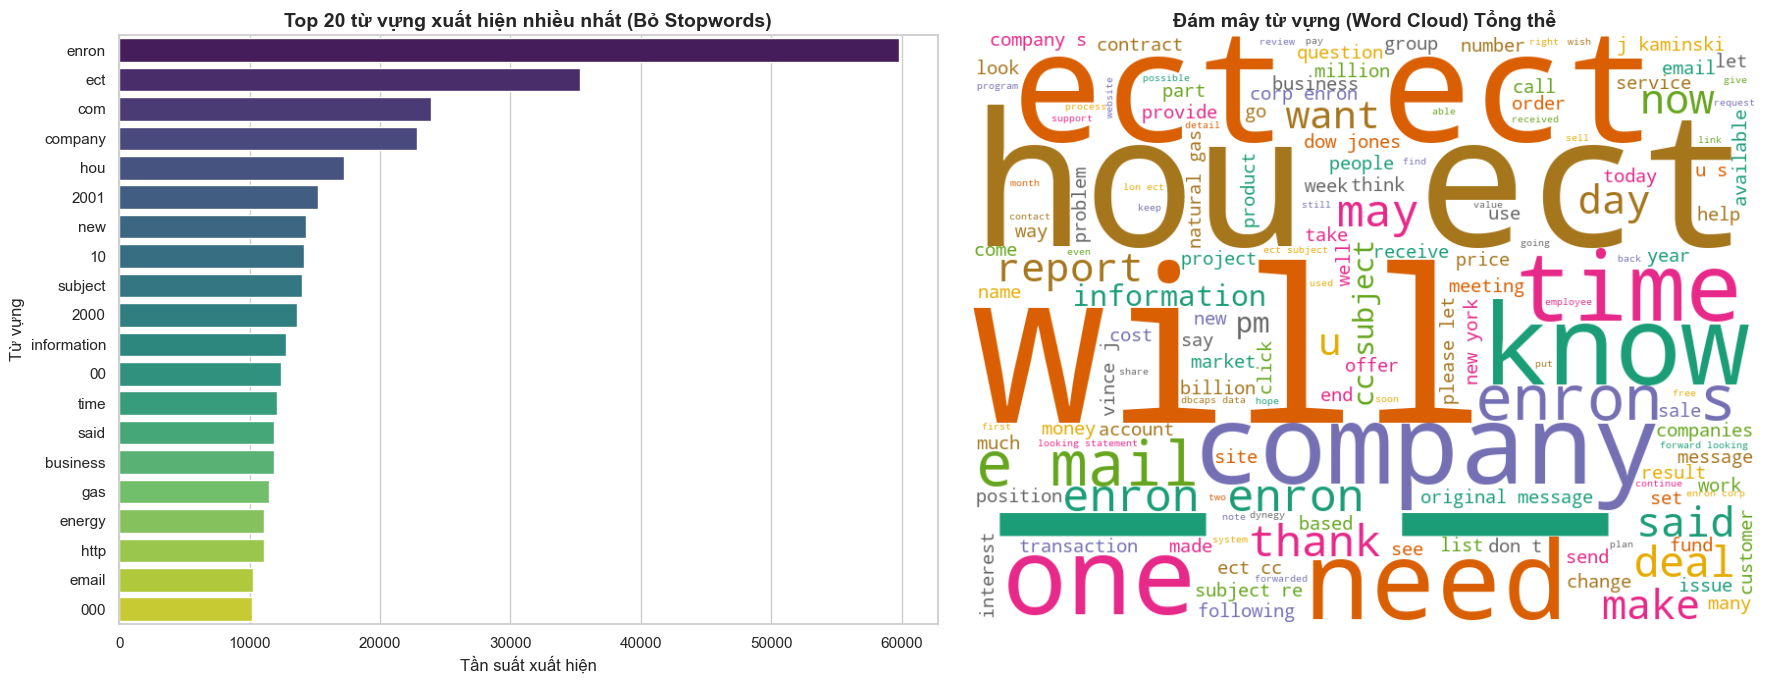

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Tần suất', y='Từ vựng', data=df_words, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 từ vựng xuất hiện nhiều nhất (Bỏ Stopwords)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tần suất xuất hiện')
axes[0].set_ylabel('Từ vựng')

wordcloud_all = WordCloud(width=800, height=600, background_color='white', 
                          colormap='Dark2', max_words=150).generate(all_text)
axes[1].imshow(wordcloud_all, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title('Word Cloud Tổng thể', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa trên biểu đồ Top 20 từ vựng xuất hiện nhiều nhất và Word Cloud tổng thể (sau khi đã loại bỏ các Stopwords tiếng Anh cơ bản), nhóm phát hiện ra 3 Insight mang tính quyết định đến hiệu năng của mô hình sau này:
- Các từ chiếm đỉnh bảng với tần suất khổng lồ là: enron (tên công ty), ect (Enron Capital & Trade - một công ty con), hou (Houston - trụ sở chính), gas, energy, corp, company. Do bộ dữ liệu này được trích xuất từ vụ bê bối rò rỉ email nội bộ của tập đoàn năng lượng Enron, nên sự xuất hiện dày đặc của các từ vựng mang tính định danh công ty và ngành nghề này là điều tất yếu. Tuy nhiên, chúng xuất hiện ở gần như mọi email công việc, do đó chúng không có khả năng phân biệt giữa thư thường và thư rác
- Các từ như subject, message, com, http, pm (giờ chiều), th (hậu tố ngày tháng, ví dụ 12th) vẫn chễm chệ trong Top 20. Sự xuất hiện của http và com hoàn toàn khớp với Insight ở phần phân tích Ký tự đặc biệt (sự lọt top của dấu / và dấu .), củng cố thêm bằng chứng về việc email chứa một lượng lớn đường link URL. Các chữ như subject hay message chỉ là các nhãn cấu trúc của một bức thư điện tử, không mang ý nghĩa nội dung
- Mặc dù nhóm đã dùng hàm loại bỏ Stopwords chuẩn của tiếng Anh (như the, is, at, which), nhưng các từ ở Top 20 này thực chất chính là Stopwords của riêng bộ dữ liệu Enron. Nếu giữ lại enron hay ect, thuật toán TF-IDF sẽ đánh trọng số cực cao cho chúng vì tần suất quá lớn, làm lu mờ đi những từ khóa thực sự quan trọng dùng để bắt rác